In [3]:
# import necessary libraries:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [4]:
# run code from data_input folder:
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [6]:
df_factors = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
df_factors = df_factors.set_index('Date')

df_benchmark = pd.read_csv("benchmark_returns.csv", parse_dates=['Date'])
df_benchmark = df_benchmark.set_index('Date')

data = pd.concat([df_benchmark,df_factors], axis=1, join='inner')
data = data.dropna()

In [7]:
print(data)

            Benchmark  Momentum  Value  Quality
Date                                           
2007-02-01       0.03      0.02   0.02     0.03
2007-03-01       0.01      0.07   0.04     0.05
2007-04-01       0.06      0.05   0.07     0.05
2007-05-01       0.05     -0.01  -0.01     0.00
2007-06-01       0.00     -0.02  -0.02    -0.01
...               ...       ...    ...      ...
2023-10-01      -0.03     -0.03  -0.06    -0.03
2023-11-01      -0.03      0.10   0.06     0.09
2023-12-01       0.08      0.01   0.04     0.02
2024-01-01       0.03     -0.02  -0.05    -0.03
2024-02-01      -0.03     -0.02  -0.05    -0.01

[205 rows x 4 columns]


In [ ]:
# List of factor columns and the benchmark
cols = ['Benchmark','Momentum', 'Value', 'Quality']

# Compute cumulative returns for each column
cum_returns = (1 + data[cols]).cumprod() - 1

# Optional: format as percentages
#cum_returns = cum_returns * 100

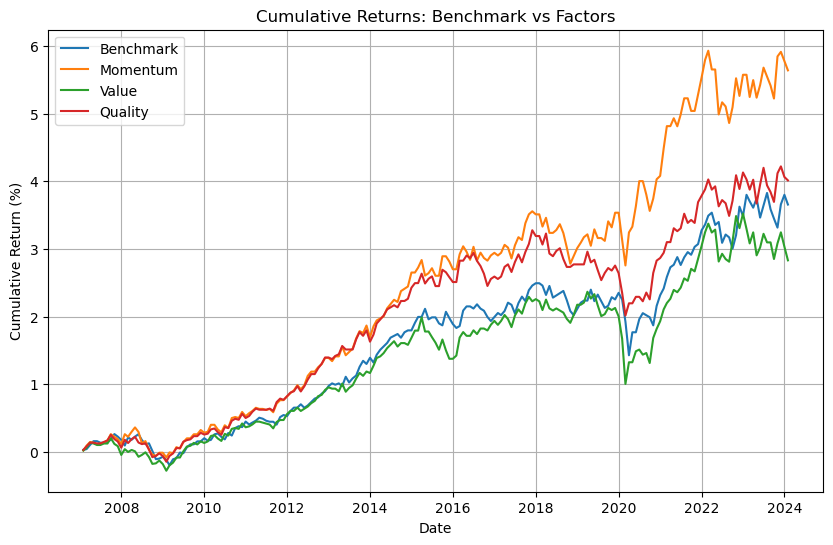

In [24]:
plt.figure(figsize=(10, 6))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title("Cumulative Returns: Benchmark vs Factors")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)
plt.show()